<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

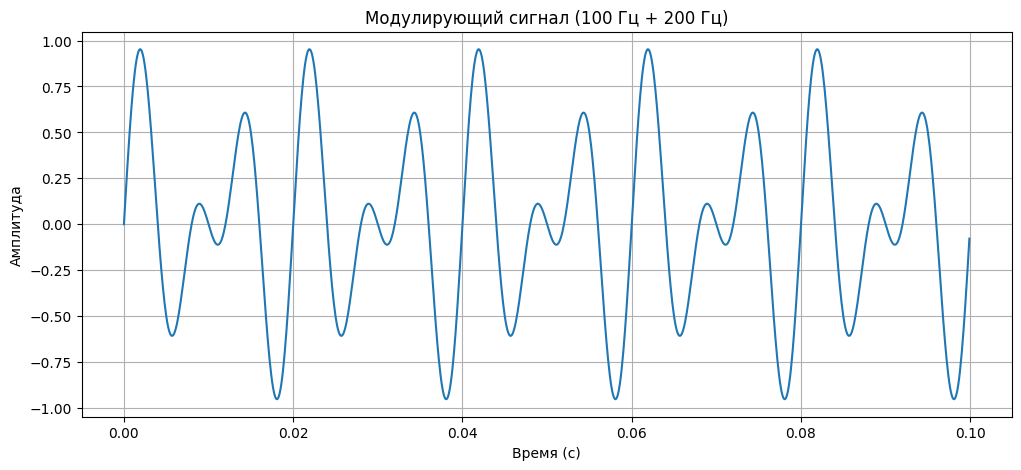

In [2]:
fm1 = 100
fm2 = 150
m_t = 0.5 * (np.sin(2 * np.pi * fm1 * t) + np.sin(2 * np.pi * fm2 * t)) # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [3]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2 * np.pi * fc * t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [4]:
beta_pm = 5
s_pm = Ac * np.cos(2 * np.pi * fc * t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

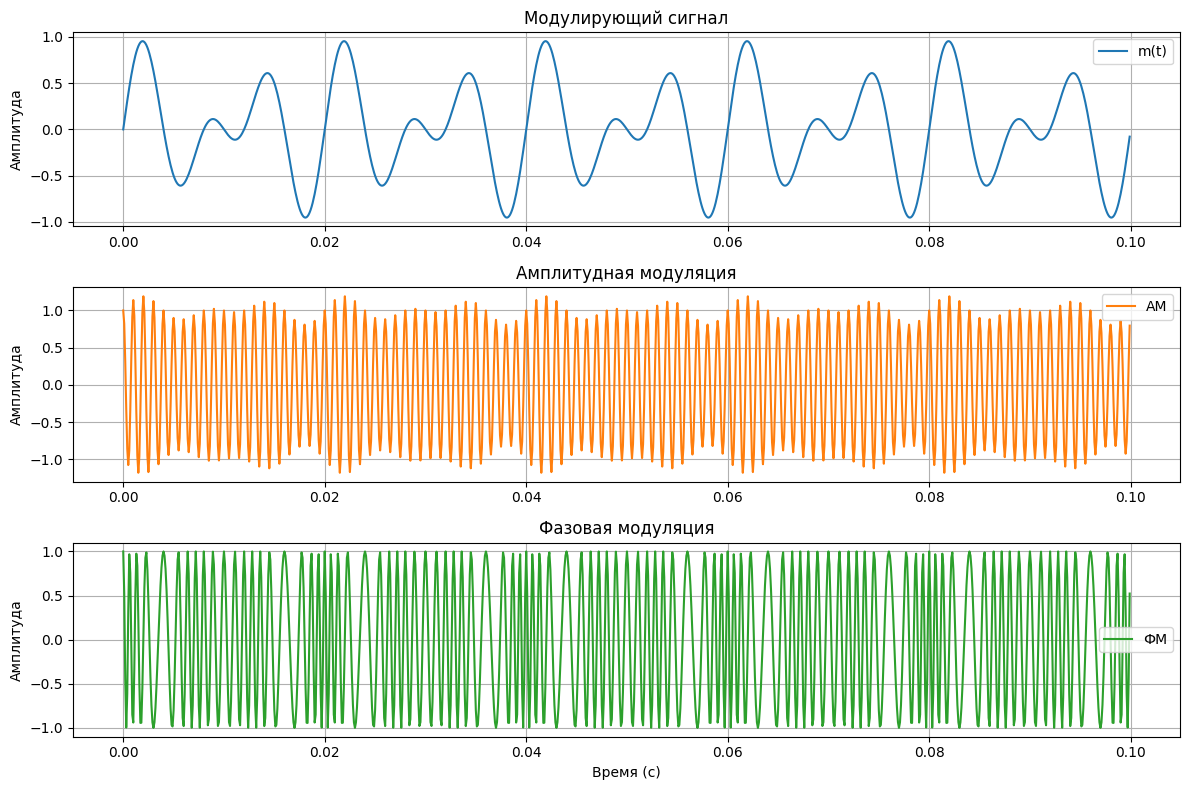

In [5]:
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(3, 1, 1)
ax1.plot(t, m_t, label='m(t)')
ax1.set_ylabel('Амплитуда')
ax1.set_title('Модулирующий сигнал')
ax1.grid(True)
ax1.legend()

ax2 = plt.subplot(3, 1, 2, sharex=ax1)
ax2.plot(t, s_am, label='АМ', color='C1')
ax2.set_ylabel('Амплитуда')
ax2.set_title('Амплитудная модуляция')
ax2.grid(True)
ax2.legend()

ax3 = plt.subplot(3, 1, 3, sharex=ax1)
ax3.plot(t, s_pm, label='ФМ', color='C2')
ax3.set_xlabel('Время (с)')
ax3.set_ylabel('Амплитуда')
ax3.set_title('Фазовая модуляция')
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()


## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [6]:
def plot_spectrum(s, fs, title):
    s = np.asarray(s)
    n = len(s)

    X = np.fft.rfft(s)
    freqs = np.fft.rfftfreq(n, 1 / fs)
    amp = (2.0 / n) * np.abs(X)

    amp[0] = np.abs(X[0]) / n
    if n % 2 == 0:
        amp[-1] = np.abs(X[-1]) / n

    plt.figure()
    plt.plot(freqs, amp)
    plt.title(title)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.show()

### 2.2. Спектр АМ

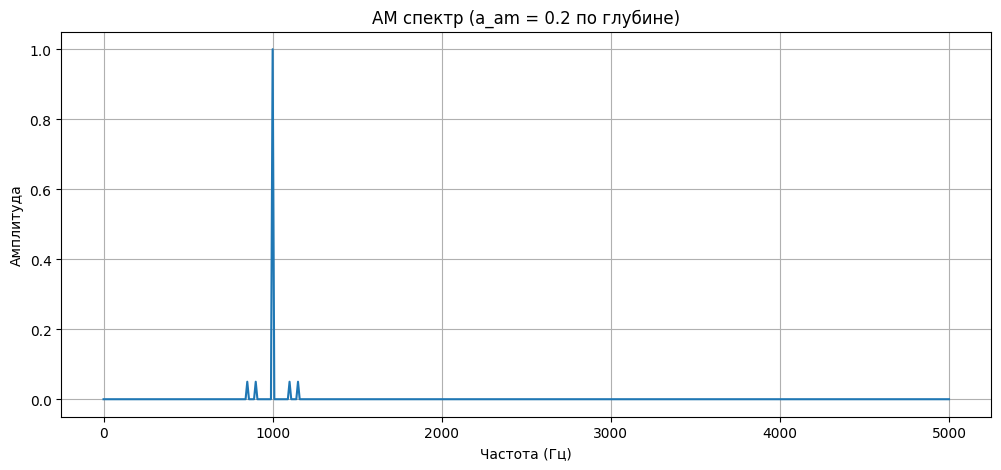

In [7]:
plot_spectrum(s_am, fs, f'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

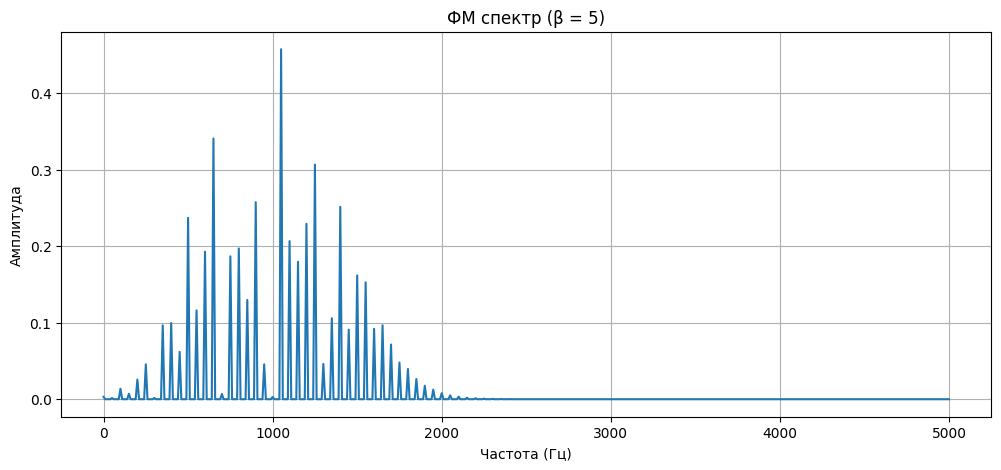

In [8]:
plot_spectrum(s_pm, fs, f'ФМ спектр ($\beta$ = {beta_pm})')


Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, $\beta$ = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.


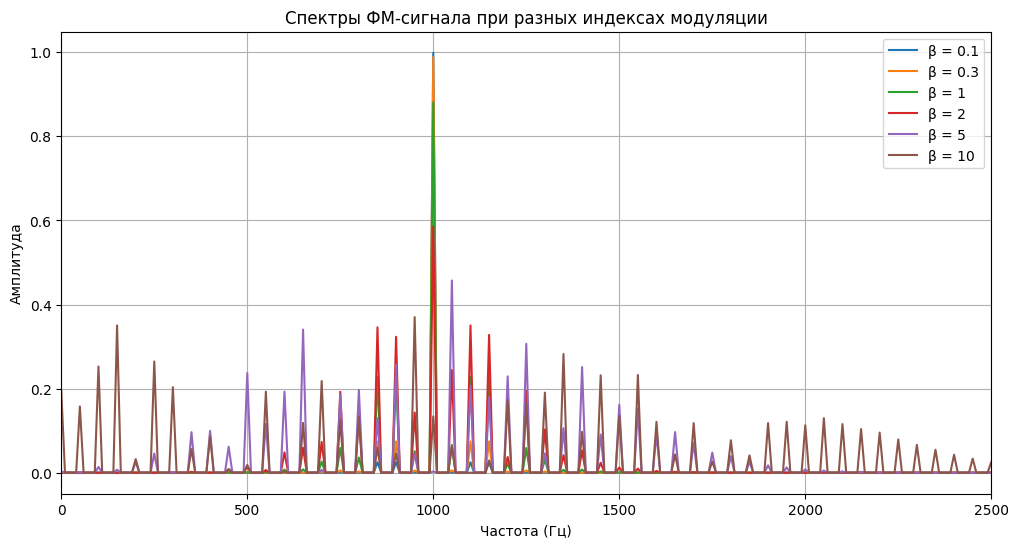

In [9]:
betas = [0.1, 0.3, 1, 2, 5, 10]

plt.figure(figsize=(12, 6))

for beta in betas:
    s = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)

    n = len(s)
    X = np.fft.rfft(s)
    freqs = np.fft.rfftfreq(n, 1 / fs)
    amp = (2.0 / n) * np.abs(X)

    amp[0] = np.abs(X[0]) / n
    if n % 2 == 0:
        amp[-1] = np.abs(X[-1]) / n

    plt.plot(freqs, amp, label=f'$\beta$ = {beta}')

plt.title('Спектры ФМ-сигнала при разных индексах модуляции')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 2500)
plt.grid(True)
plt.legend()
plt.show()


### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [10]:
def pm_spectrum(beta=5):
    s = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)
    plot_spectrum(s, fs, f'ФМ спектр ($\beta$ = {beta})')


widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));


interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых $\beta$?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении $\beta$?


1) Потому что в модулирующем сигнале есть только две частоты, 100 и 150 Гц. Каждая из них при умножении даёт по две боковые полосы, а несущая остаётся на частоте fc
2) При малых $\beta$ спектр ФМ узкополосен: доминирует несущая и видна в основном первая пара боковых полос
3) При увеличении $\beta$ амплитуда несущей уменьшается, энергия перераспределяется по большему числу боковых полос, и спектр расширяется


## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

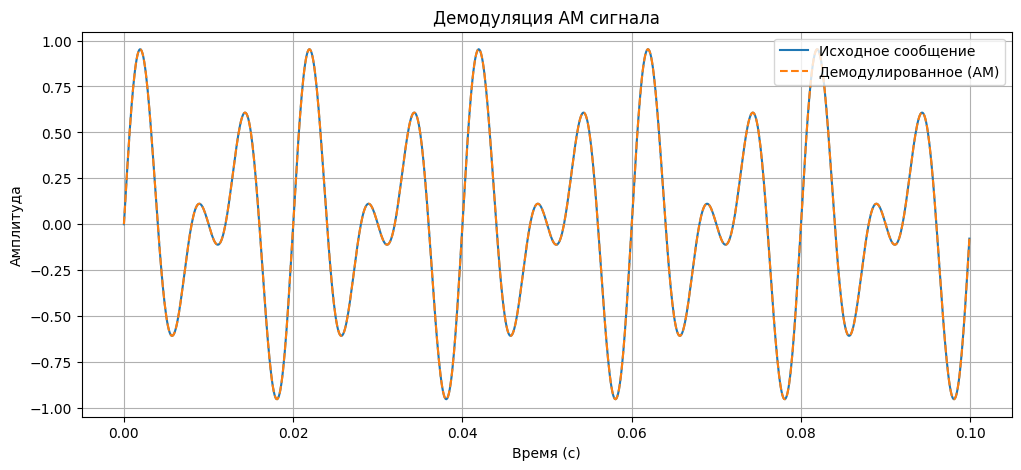

In [11]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [12]:
error_am = np.std(m_t - demod_am)
print(f'Ошибка для АМ-демодуляции: {error_am:.6e}')

Ошибка для АМ-демодуляции: 8.092481e-14


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

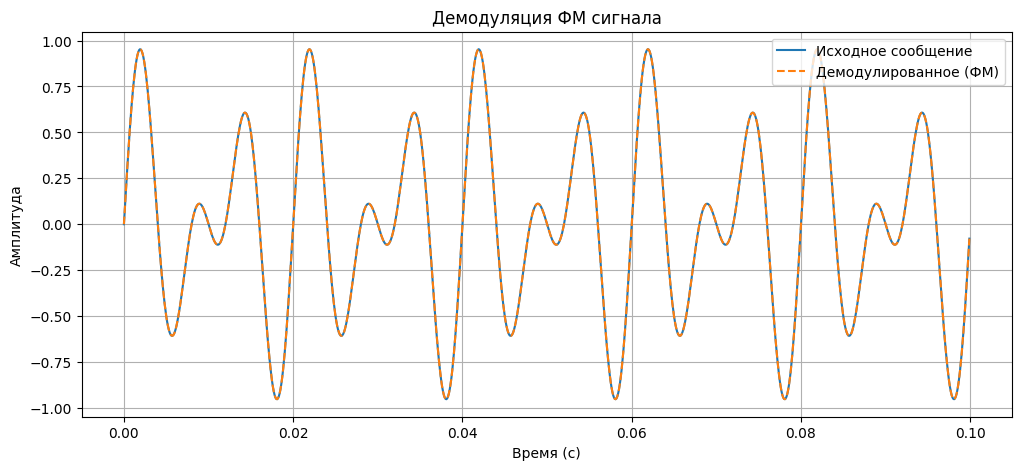

In [13]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?


Потому что `np.angle` возвращает фазу в диапазоне [-$\pi$, $\pi$], из-за чего возникают скачки на $2\pi$. `np.unwrap` убирает эти скачки


## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [18]:
fs_audio, melody_stereo = wavfile.read('../data/sample-3s.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

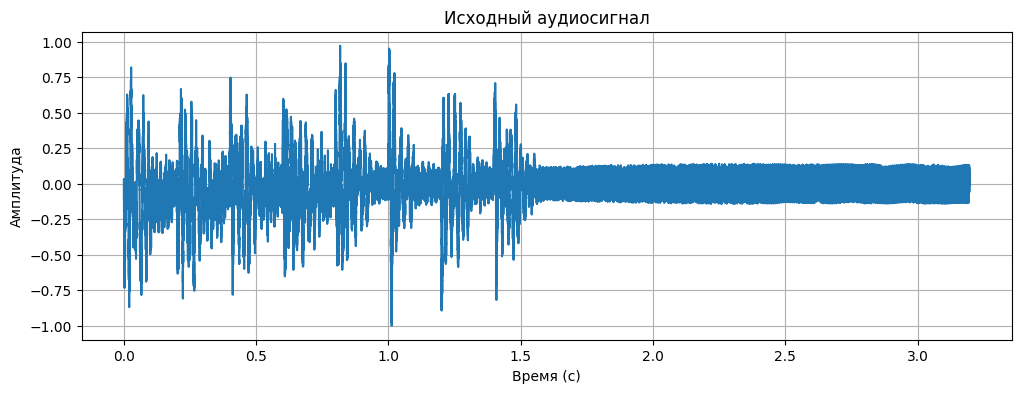

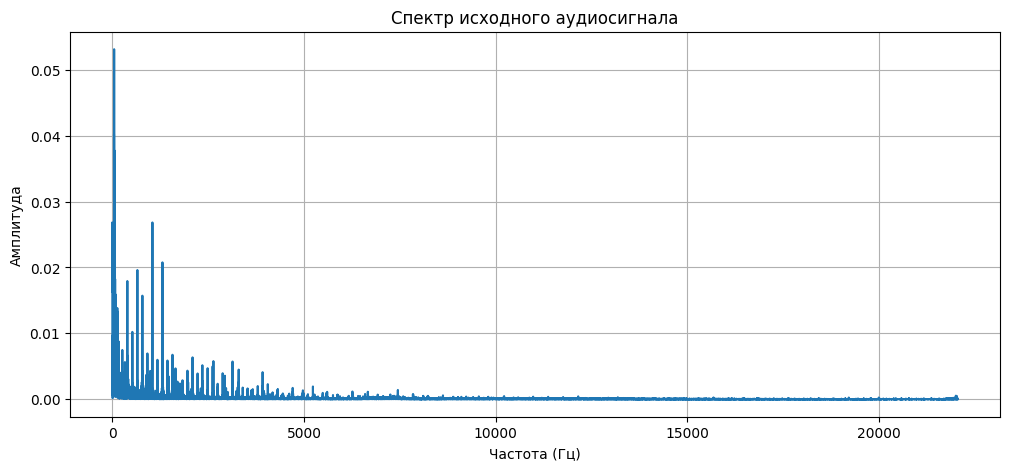

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(t_audio, melody)
plt.title('Исходный аудиосигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

plot_spectrum(melody, fs_audio, 'Спектр исходного аудиосигнала')


**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

1) В основном до примерно 3-4 кГц
2) Около 5 кГц
3) При увеличении индекса модуляции $\beta$ спектр ФМ расширяется, поэтому нужен больший запас полосы вокруг несущей


### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [20]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [ ]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [54]:
noise_amp = 0.05 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [55]:
analytic_am_audio = hilbert(s_am_audio)
envelope_am_audio = np.abs(analytic_am_audio)

demod_am_audio = (envelope_am_audio - Ac) / a_am
demod_am_audio = demod_am_audio - np.mean(demod_am_audio)
demod_am_audio = demod_am_audio / np.max(np.abs(demod_am_audio))

print("Демодулированный АМ-сигнал без шума:")
display(Audio(demod_am_audio, rate=fs_audio))


Демодулированный АМ-сигнал без шума:


Демодулируйте зашумлёный АМ-сигнал.

In [56]:
analytic_am_noisy = hilbert(s_am_noisy)
envelope_am_noisy = np.abs(analytic_am_noisy)

demod_am_noisy_audio = (envelope_am_noisy - Ac) / a_am
demod_am_noisy_audio = demod_am_noisy_audio - np.mean(demod_am_noisy_audio)
demod_am_noisy_audio = demod_am_noisy_audio / np.max(np.abs(demod_am_noisy_audio))

print("Демодулированный АМ-сигнал с шумом:")
display(Audio(demod_am_noisy_audio, rate=fs_audio))


Демодулированный АМ-сигнал с шумом:


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

1) Да
2) При a_AM=0.2 примерно при амплитуде шума 0.03-0.05, а при 0.1 искажения уже сильные
3) При шуме 0.01 заметные искажения начинаются при малых глубинах модуляции, примерно при a_AM<0.1. При a_AM около 0.2 качество уже приемлемое, а при 0.4-0.8 восстановление становится лучше. Чем больше a_AM, тем больший уровень амплитудного шума допустим


**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [57]:
analytic_pm_audio = hilbert(s_pm_audio)
inst_phase_audio = np.unwrap(np.angle(analytic_pm_audio))

phase_no_carrier_audio = inst_phase_audio - 2 * np.pi * fc_high * t_audio

demod_pm_audio = phase_no_carrier_audio - np.mean(phase_no_carrier_audio)
demod_pm_audio = demod_pm_audio / beta_pm_audio
demod_pm_audio = demod_pm_audio / np.max(np.abs(demod_pm_audio))

print("Демодулированный ФМ-сигнал без шума:")
display(Audio(demod_pm_audio, rate=fs_audio))

Демодулированный ФМ-сигнал без шума:


Демодулируйте зашумлёный ФМ-сигнал.

In [59]:
analytic_pm_noisy = hilbert(s_pm_noisy)
inst_phase_noisy = np.unwrap(np.angle(analytic_pm_noisy))

phase_no_carrier_noisy = inst_phase_noisy - 2 * np.pi * fc_high * t_audio

demod_pm_noisy_audio = phase_no_carrier_noisy - np.mean(phase_no_carrier_noisy)
demod_pm_noisy_audio = demod_pm_noisy_audio / beta_pm_audio
demod_pm_noisy_audio = demod_pm_noisy_audio / np.max(np.abs(demod_pm_noisy_audio))

print("Демодулированный ФМ-сигнал с шумом:")
display(Audio(demod_pm_noisy_audio, rate=fs_audio))

Демодулированный ФМ-сигнал с шумом:


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

1) Да, но при том же шуме ФМ портится слабее, чем АМ
2) При $\beta=2$ разница появляется примерно при амплитуде шума 0.1
3) При шуме 0.1 чем больше $\beta$, тем меньше искажения: при $\beta$ около 0.5-1 они заметны, при $\beta$ около 2 уже хорошо, а при $\beta=4-8$ ещё лучше


### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

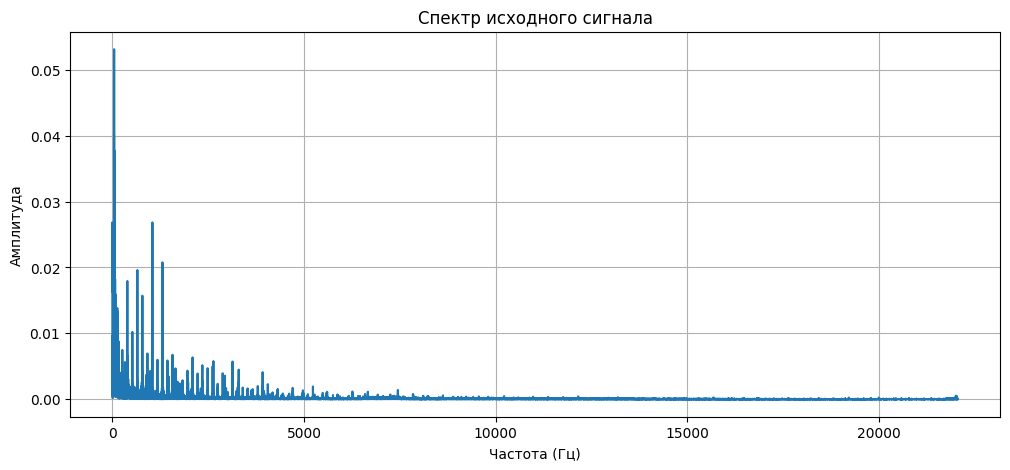

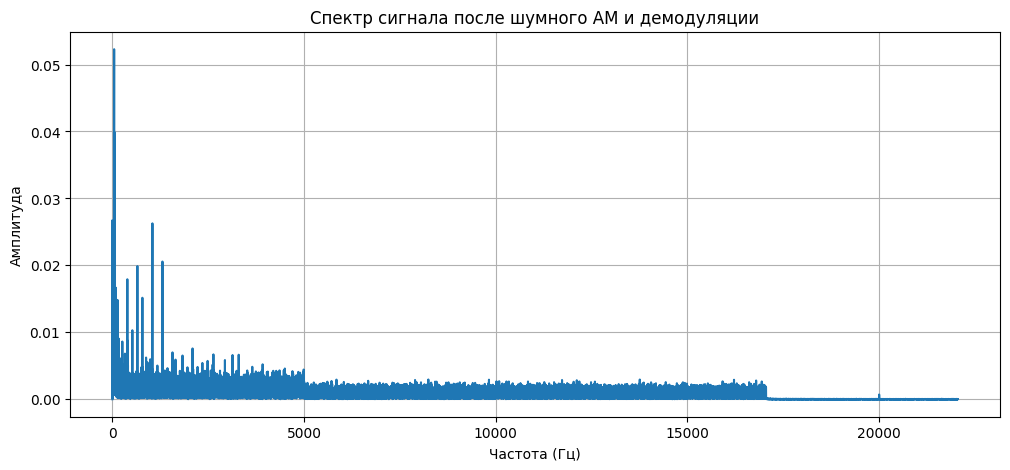

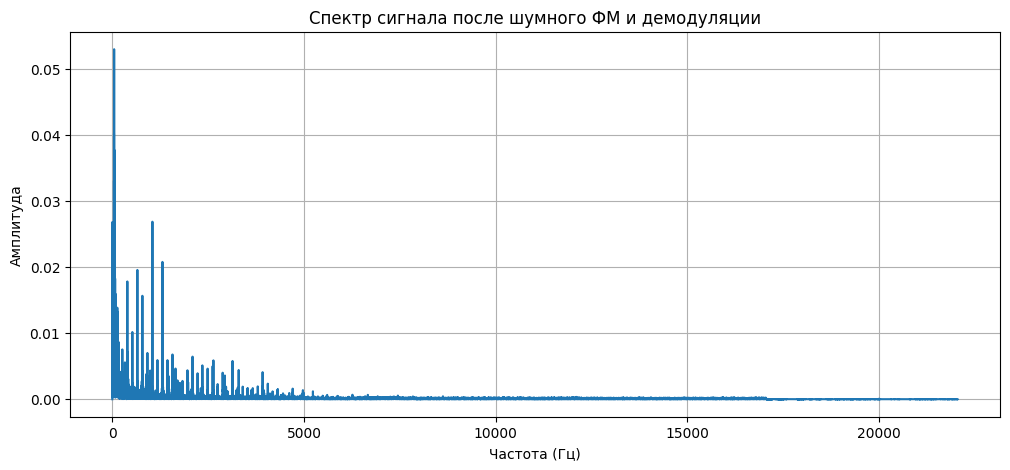

In [60]:
noise_level_compare = 0.05
a_am_compare = 0.2
beta_compare = 2

rng = np.random.default_rng(0)
noise_compare = noise_level_compare * rng.standard_normal(len(t_audio))

s_am_compare = Ac * (1 + a_am_compare * melody) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_compare = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_compare * melody)

s_am_compare_noisy = s_am_compare * (1 + noise_compare)
s_pm_compare_noisy = s_pm_compare * (1 + noise_compare)

demod_am_compare = (np.abs(hilbert(s_am_compare_noisy)) - Ac) / a_am_compare
demod_am_compare = demod_am_compare - np.mean(demod_am_compare)

phase_pm_compare = np.unwrap(np.angle(hilbert(s_pm_compare_noisy)))
demod_pm_compare = phase_pm_compare - 2 * np.pi * fc_high * t_audio
demod_pm_compare = demod_pm_compare - np.mean(demod_pm_compare)
demod_pm_compare = demod_pm_compare / beta_compare

plot_spectrum(melody, fs_audio, 'Спектр исходного сигнала')
plot_spectrum(demod_am_compare, fs_audio, 'Спектр сигнала после шумного АМ и демодуляции')
plot_spectrum(demod_pm_compare, fs_audio, 'Спектр сигнала после шумного ФМ и демодуляции')


**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

Да. У АМ искажения сильнее: пики сильнее размываются и растёт шумовой фон. 

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

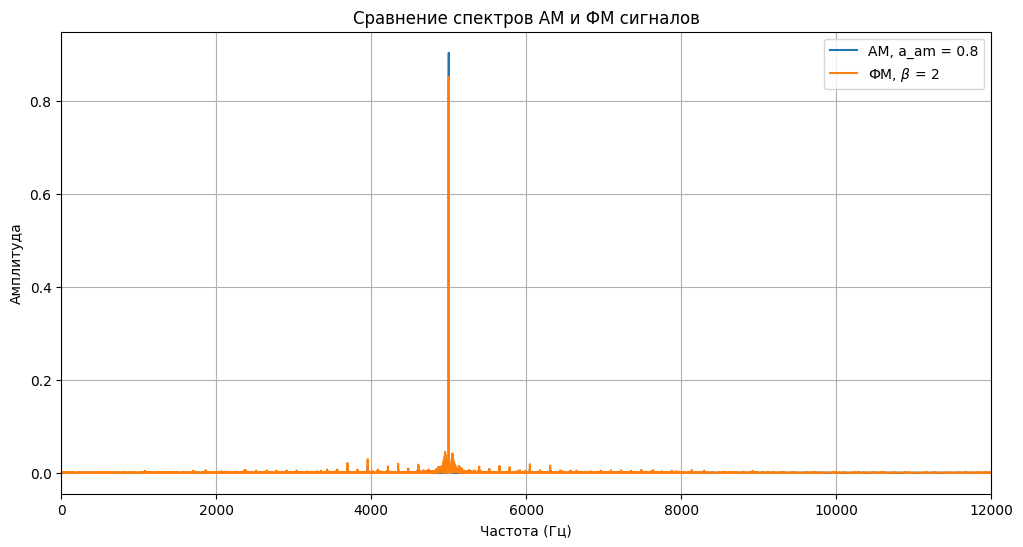

In [64]:
a_am_compare = 0.8
beta_compare = 2

s_am_compare = Ac * (1 + a_am_compare * melody) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_compare = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_compare * melody)

n = len(melody)
freqs = np.fft.rfftfreq(n, 1 / fs_audio)

X_am = np.fft.rfft(s_am_compare)
amp_am = (2.0 / n) * np.abs(X_am)
amp_am[0] = np.abs(X_am[0]) / n

X_pm = np.fft.rfft(s_pm_compare)
amp_pm = (2.0 / n) * np.abs(X_pm)
amp_pm[0] = np.abs(X_pm[0]) / n

plt.figure(figsize=(12, 6))
plt.plot(freqs, amp_am, label=f'АМ, a_am = {a_am_compare}')
plt.plot(freqs, amp_pm, label=f'ФМ, $\\beta$ = {beta_compare}')
plt.title('Сравнение спектров АМ и ФМ сигналов')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 12000)
plt.grid(True)
plt.legend()
plt.show()


**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

1) У АМ заметные искажения обычно начинают появляться уже при шуме порядка 0.05-0.1
2) У ФМ при тех же условиях заметные искажения появляются позже, ближе к 0.1-0.2
3) Вывод: при сопоставимых спектрах ФМ устойчивее к амплитудному шуму, потому что информация в ней сидит в фазе, а не в амплитуде
